# A3I Project — Day-Ahead Price Prediction and Battery Arbitrage

End-to-end pipeline from raw market/meteorological data to a decision-focused
learning (DFL) policy for battery arbitrage on the Italian day-ahead market
(IT_NORD zone).

The notebook is organised in five blocks:

1. **Setup and data ingestion** — ENTSO-E prices + Open-Meteo weather, aligned on UTC.
2. **Feature engineering** — cyclical time encoding, autoregressive lags, rolling stats.
3. **Anomaly detection** — an autoencoder to isolate the 2021-2022 regime shift.
4. **Price prediction** — XGBoost regression with SHAP explainability.
5. **Decision-focused learning** — PFL vs DFL on the battery arbitrage task,
   with a physical LCOS constraint folded into the training objective.


## 1. Setup

All imports, seeds, constants and side-effect-free setup live here so every
downstream cell can be re-run independently without surprises.

The ENTSO-E API token is read from the `ENTSOE_API_KEY` environment variable:
hard-coding it in the notebook would leak it the moment the file is shared.


In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import pytz

from entsoe import EntsoePandasClient
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

import xgboost as xgb
import shap

import torch
import torch.nn as nn
import torch.optim as optim

# --- reproducibility -------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# --- plotting defaults ----------------------------------------------
sns.set_theme(style="whitegrid")
os.makedirs("images", exist_ok=True)

# --- geographical / temporal scope ----------------------------------
LATITUDE  = 44.49       # Bologna
LONGITUDE = 11.34
START_DATE = "2019-01-01"
END_DATE   = "2025-12-31"
COUNTRY_CODE = "IT_NORD"

# --- credentials -----------------------------
ENTSOE_TOKEN = "14456526-8054-4a1b-9600-49167bdf441b"
if not ENTSOE_TOKEN:
    raise EnvironmentError(
        "Set the ENTSOE_API_KEY environment variable before running this notebook "
        "(you can request a token at https://transparency.entsoe.eu/)."
    )


c:\Users\Carmine2\Desktop\Università-Magistrale\Year_2\AI4I\Energy-Arbitrage-DFL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Ingestion and Market Context

Forecasting day-ahead electricity prices requires capturing both the
supply-side constraints and the demand-side behaviour of the power grid.
The pipeline integrates two primary sources:

* **Meteorological data (Open-Meteo archive API).** Temperature, direct
  solar radiation and wind speed are the exogenous drivers behind the
  *merit-order effect*: a large renewable injection (near-zero marginal cost)
  structurally depresses wholesale clearing prices.
* **Market clearing prices (ENTSO-E API).** The historical day-ahead prices
  for the IT_NORD bidding zone are the target variable.

Both datasets are aligned strictly on UTC, which is the only timestamp that
is well-behaved across Daylight Saving Time transitions.


In [2]:
def fetch_weather_features(lat, lon, start_date, end_date):
    """Pull hourly temperature, direct radiation and wind speed from Open-Meteo.

    No API key is required; the archive endpoint serves reanalysis data.
    """
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={lat}&longitude={lon}"
        f"&start_date={start_date}&end_date={end_date}"
        "&hourly=temperature_2m,direct_radiation,windspeed_10m&timezone=UTC"
    )
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        print(f"Open-Meteo API error: {r.status_code}")
        return None

    df = pd.DataFrame(r.json()["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")
    df.index = df.index.tz_localize("UTC")
    df.columns = ["Temperature_C", "Solar_Radiation_W", "Wind_Speed_ms"]
    print(f"Weather data: {len(df):,} hourly records.")
    return df


def fetch_energy_prices(api_token, country_code, start_date, end_date):
    """Pull day-ahead clearing prices (EUR/MWh) from ENTSO-E.

    Strings are converted to tz-aware timestamps in Europe/Rome (the bidding
    zone's local time), and the returned index is then cast back to UTC to
    match the weather data.
    """
    client = EntsoePandasClient(api_key=api_token)
    tz = pytz.timezone("Europe/Rome")
    start = pd.Timestamp(start_date, tz=tz)
    end   = pd.Timestamp(end_date,   tz=tz)

    try:
        ts = client.query_day_ahead_prices(country_code, start=start, end=end)
        df = pd.DataFrame(ts, columns=["Day_Ahead_Price_EUR_MWh"])
        df.index.name = "time"
        df.index = df.index.tz_convert("UTC")
        print(f"Prices ({country_code}): {len(df):,} hourly records.")
        return df
    except Exception as e:
        print(f"ENTSO-E API error: {e}")
        return None


We fetch the full weather window in a single call (the Open-Meteo archive
endpoint is cheap and doesn't rate-limit meaningfully at this scale), and we
fetch prices **year by year** to stay under ENTSO-E's per-request limits and
to recover gracefully if a single year fails.


In [3]:
df_weather = fetch_weather_features(LATITUDE, LONGITUDE, START_DATE, END_DATE)

yearly_prices = []
for year in range(2019, 2026):
    df_year = fetch_energy_prices(
        ENTSOE_TOKEN, COUNTRY_CODE,
        f"{year}-01-01", f"{year}-12-31",
    )
    if df_year is not None:
        yearly_prices.append(df_year)
    time.sleep(1)                               # polite pause between requests

df_prices = pd.concat(yearly_prices)
df_prices = df_prices[~df_prices.index.duplicated(keep="first")]
print(f"\nTotal price hours after deduplication: {len(df_prices):,}")


Weather data: 61,368 hourly records.
Prices (IT_NORD): 8,736 hourly records.
Prices (IT_NORD): 8,760 hourly records.
Prices (IT_NORD): 8,736 hourly records.
Prices (IT_NORD): 8,736 hourly records.
Prices (IT_NORD): 8,736 hourly records.
Prices (IT_NORD): 8,760 hourly records.
Prices (IT_NORD): 15,291 hourly records.

Total price hours after deduplication: 67,755


## 3. Feature Engineering

### 3.1 Cyclical encoding of time

Representing the hour of day as an integer 0..23 introduces a spurious
distance between hour 23 and hour 0, whereas those two hours are actually
*adjacent* on the clock. Projecting the hour onto the unit circle with
$\sin(2\pi h / 24)$, $\cos(2\pi h / 24)$ fixes this: the wrap-around becomes
continuous, and tree-based and distance-based learners can recover daily
and seasonal periodicities naturally. The same transformation is applied
to the month-of-year.

### 3.2 Autoregressive memory

Energy prices are sticky: today's 18:00 price is correlated with yesterday's
18:00 price (daily seasonality) and with last Tuesday's 18:00 price (weekly
seasonality, driven by industrial demand cycles). We encode this with two
lag features and a rolling mean *of the lag* — never of the target at time
$t$ — which mathematically prevents look-ahead bias.


In [4]:
df_features = df_weather.copy()

# --- temporal markers ------------------------------------------------
df_features["Hour"]       = df_features.index.hour
df_features["DayOfWeek"]  = df_features.index.dayofweek
df_features["Month"]      = df_features.index.month
df_features["Is_Weekend"] = (df_features["DayOfWeek"] >= 5).astype(int)

# --- cyclical encoding ----------------------------------------------
df_features["Hour_Sin"]  = np.sin(2 * np.pi * df_features["Hour"]  / 24.0)
df_features["Hour_Cos"]  = np.cos(2 * np.pi * df_features["Hour"]  / 24.0)
df_features["Month_Sin"] = np.sin(2 * np.pi * df_features["Month"] / 12.0)
df_features["Month_Cos"] = np.cos(2 * np.pi * df_features["Month"] / 12.0)

# --- join with the price target -------------------------------------
df_ml = df_features.join(df_prices, how="inner").copy()

# --- lag features (leakage-safe) ------------------------------------
df_ml["Price_Lag_24h"]  = df_ml["Day_Ahead_Price_EUR_MWh"].shift(24)    # daily
df_ml["Price_Lag_168h"] = df_ml["Day_Ahead_Price_EUR_MWh"].shift(168)   # weekly

# Rolling mean is computed on the LAG, not on the current price: this is
# what makes the feature safe to use at inference time.
df_ml["Price_Rolling_Mean_24h"] = (
    df_ml["Price_Lag_24h"].rolling(window=24, min_periods=1).mean()
)

df_ml = df_ml.dropna()
print(f"Final aligned dataset: {df_ml.shape[0]:,} hours, {df_ml.shape[1]} features.")


Final aligned dataset: 61,031 hours, 15 features.


A small visual sanity check: the first 48 hours of the cyclical encoding
should land exactly on the unit circle, with hour 23 next to hour 0 rather
than at the other end of the axis.


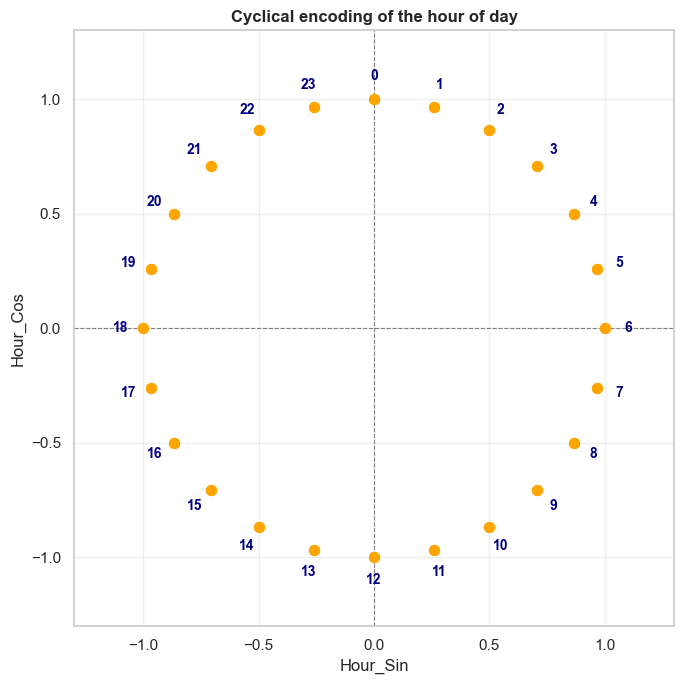

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_features["Hour_Sin"][:48], df_features["Hour_Cos"][:48],
           color="orange", s=50, zorder=5)
for h in range(24):
    ax.text(np.sin(2 * np.pi * h / 24) * 1.1,
            np.cos(2 * np.pi * h / 24) * 1.1,
            str(h), ha="center", va="center",
            fontsize=10, fontweight="bold", color="navy")
ax.set_title("Cyclical encoding of the hour of day", fontweight="bold")
ax.set_xlabel("Hour_Sin"); ax.set_ylabel("Hour_Cos")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/Cyclical_Encoding.png", dpi=200)
plt.show()


### 3.3 Correlation overview

Pearson correlation between the target and the main inputs confirms the
textbook intuition:

* Strong positive correlation with `Price_Lag_24h` and `Price_Lag_168h`
  (persistence).
* Negative correlation with `Solar_Radiation_W` (merit-order effect).


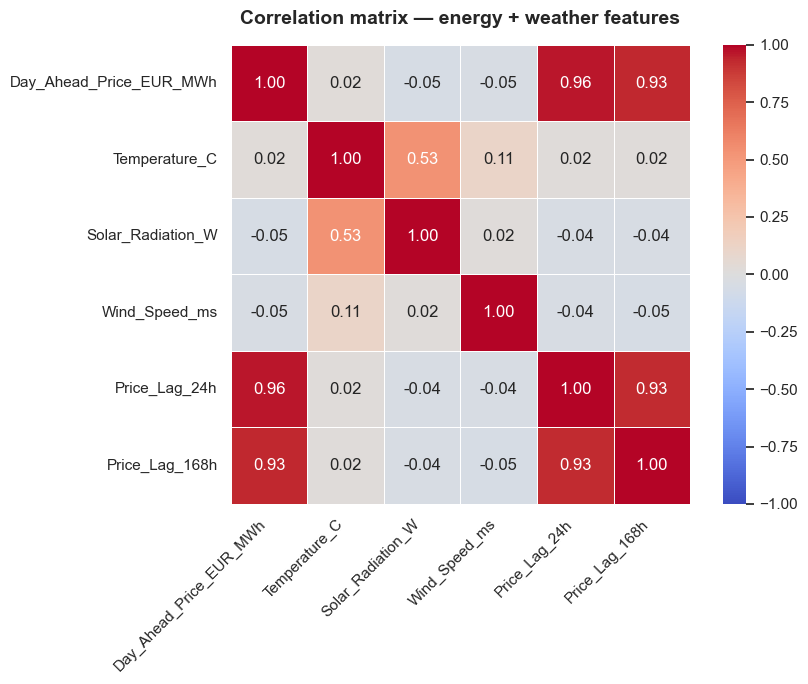

In [6]:
cols_to_plot = [
    "Day_Ahead_Price_EUR_MWh", "Temperature_C",
    "Solar_Radiation_W", "Wind_Speed_ms",
    "Price_Lag_24h", "Price_Lag_168h",
]
corr = df_ml[cols_to_plot].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title("Correlation matrix — energy + weather features",
          fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/Energy_Correlation_Matrix.png", dpi=200)
plt.show()


## 4. Autoencoder-based Anomaly Detection

Data stationarity is a convenient assumption that is routinely violated by
exogenous shocks — the 2022 gas crisis being the most dramatic recent
example in European electricity markets. Training a predictive model on a
mixture of pre-crisis, crisis and post-crisis data risks smearing these
regimes together.

An autoencoder trained exclusively on the quiet years (2019-2020) and
forced through a low-dimensional bottleneck can only reconstruct data that
lies on the "normal" manifold. When the trained network is run on later
years, its reconstruction error spikes exactly where the market deviates
from that manifold — without any manually chosen threshold or labelled
crisis period.

The critical threshold used for visualisation below is the **99th
percentile of the training-set reconstruction error**: it is a training-set
quantile, not a hold-out one, which is the honest framing.


In [7]:
# --- prepare the matrices -------------------------------------------
df_ae_all = df_ml.copy()
features_ae = [
    "Day_Ahead_Price_EUR_MWh", "Temperature_C",
    "Solar_Radiation_W", "Wind_Speed_ms", "Price_Lag_24h",
]
df_ae_normal = df_ae_all.loc["2019-01-01":"2020-12-31"]

scaler = StandardScaler().fit(df_ae_normal[features_ae])
X_normal = scaler.transform(df_ae_normal[features_ae])
X_all    = scaler.transform(df_ae_all[features_ae])

# --- autoencoder architecture ---------------------------------------
input_dim = X_normal.shape[1]
inp = Input(shape=(input_dim,))
z   = Dense(16, activation="relu")(inp)
z   = Dense(8,  activation="relu")(z)
z   = Dense(3,  activation="relu")(z)            # bottleneck
z   = Dense(8,  activation="relu")(z)
z   = Dense(16, activation="relu")(z)
out = Dense(input_dim, activation="linear")(z)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mse")

_ = autoencoder.fit(
    X_normal, X_normal,
    epochs=30, batch_size=64,
    validation_split=0.1, shuffle=True, verbose=0,
)

# --- reconstruction error across the full dataset -------------------
X_hat_all = autoencoder.predict(X_all, verbose=0)
mse_all = np.mean((X_all - X_hat_all) ** 2, axis=1)
df_ae_all["Reconstruction_Error"] = mse_all
df_ae_all["Error_Smoothed"] = (
    df_ae_all["Reconstruction_Error"].rolling(window=168, min_periods=1).mean()
)

# Threshold: 99th percentile of the *training* error
n_train = len(df_ae_normal)
critical_threshold = np.percentile(mse_all[:n_train], 99)
print(f"Critical threshold (99th pct of 2019-2020 error): {critical_threshold:.4f}")


Critical threshold (99th pct of 2019-2020 error): 0.5766


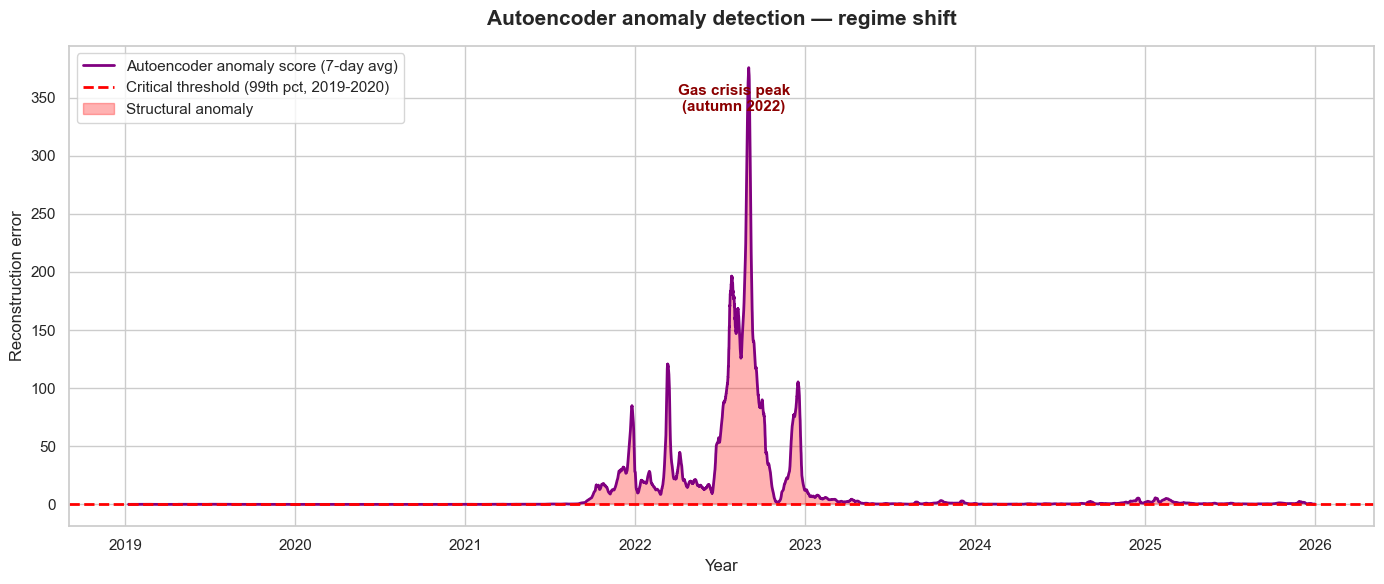

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(df_ae_all.index, df_ae_all["Error_Smoothed"],
         color="purple", linewidth=2,
         label="Autoencoder anomaly score (7-day avg)")
plt.axhline(y=critical_threshold, color="red", linestyle="--", linewidth=2,
            label="Critical threshold (99th pct, 2019-2020)")
plt.fill_between(df_ae_all.index,
                 df_ae_all["Error_Smoothed"], critical_threshold,
                 where=(df_ae_all["Error_Smoothed"] > critical_threshold),
                 color="red", alpha=0.3, label="Structural anomaly")

plt.title("Autoencoder anomaly detection — regime shift",
          fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Year"); plt.ylabel("Reconstruction error")
plt.legend(loc="upper left")
plt.text(pd.to_datetime("2022-08-01"),
         df_ae_all["Error_Smoothed"].max() * 0.9,
         "Gas crisis peak\n(autumn 2022)",
         ha="center", fontsize=11, fontweight="bold", color="darkred")
plt.tight_layout()
plt.savefig("images/Energy_Crisis_Autoencoder.png", dpi=200)
plt.show()


## 5. Price Prediction with XGBoost + SHAP

The predictive target is the day-ahead price. Split is chronological:
2019-2023 for training (with a small tail slice reserved for early
stopping), 2024-2025 for out-of-sample evaluation. This matters — a random
split would contaminate the training set with future information and make
the reported error optimistic.

Explainability is obtained with TreeSHAP on a random sample of 2000 test
rows. TreeSHAP is exact for tree ensembles and cheap enough to run on a
real sample rather than a tiny toy.


In [9]:
features_xgb = [
    "Temperature_C", "Solar_Radiation_W", "Wind_Speed_ms",
    "Hour_Sin", "Hour_Cos", "Month_Sin", "Month_Cos", "Is_Weekend",
    "Price_Lag_24h", "Price_Lag_168h", "Price_Rolling_Mean_24h",
]
target = "Day_Ahead_Price_EUR_MWh"

df_xgb_train_full = df_ml.loc["2019-01-01":"2023-12-31"]
df_xgb_test       = df_ml.loc["2024-01-01":"2025-12-31"]

# Carve off the last 10% of the training period for early stopping
split_idx = int(len(df_xgb_train_full) * 0.9)
df_xgb_train = df_xgb_train_full.iloc[:split_idx]
df_xgb_val   = df_xgb_train_full.iloc[split_idx:]

X_train, y_train = df_xgb_train[features_xgb], df_xgb_train[target]
X_val,   y_val   = df_xgb_val[features_xgb],   df_xgb_val[target]
X_test,  y_test  = df_xgb_test[features_xgb],  df_xgb_test[target]

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    early_stopping_rounds=25,
    n_jobs=-1,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred = model_xgb.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"\nHold-out performance (2024-2025):")
print(f"  MAE  = {mae:6.2f} EUR/MWh")
print(f"  RMSE = {rmse:6.2f} EUR/MWh")


Train: 39,182  |  Val: 4,354  |  Test: 17,495

Hold-out performance (2024-2025):
  MAE  =  11.27 EUR/MWh
  RMSE =  16.19 EUR/MWh


C:\Users\Carmine2\AppData\Local\Temp\ipykernel_19764\3286901319.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, show=False, cmap="coolwarm")


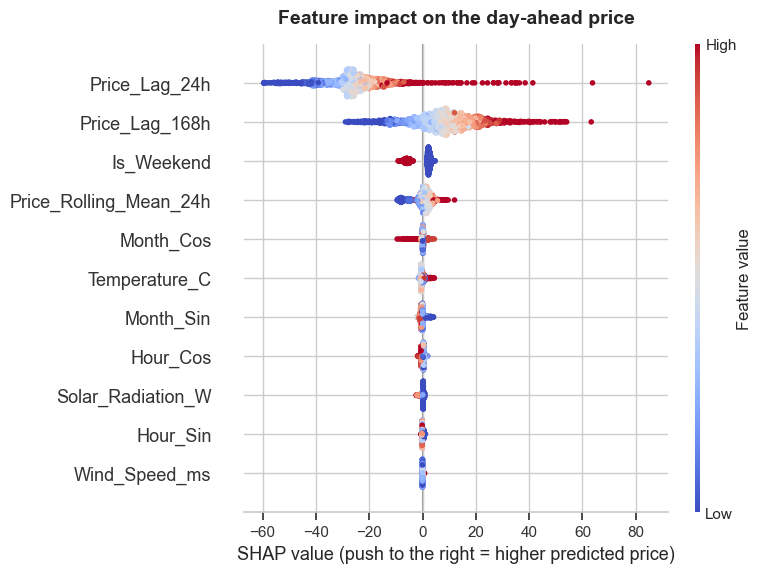

In [10]:
X_shap_sample = X_test.sample(2000, random_state=RANDOM_STATE).reset_index(drop=True)
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_shap_sample)

plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X_shap_sample, show=False, cmap="coolwarm")
plt.title("Feature impact on the day-ahead price",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("SHAP value (push to the right = higher predicted price)")
plt.tight_layout()
plt.savefig("images/Energy_SHAP_Explanation.png", dpi=200)
plt.show()


## 6. Decision-Focused Learning for Battery Arbitrage

### 6.1 The misalignment between loss and cost

A standard Predict-then-Optimize (PFL) pipeline trains the predictor to
minimise a statistical loss (MSE here) and then feeds the predictions to
an optimizer. As discussed in the lecture notes (`01__Loss_vs_Cost.ipynb`),
this is asymptotically correct but in practice creates a mismatch: the
model may be very accurate *on average* while being systematically wrong
at the moments that matter most for the downstream decision — in our case,
the daily price peak and trough.

Decision-focused learning (DFL) aligns training with the downstream cost
by minimising the **regret**:

$$
\text{regret}(y,\hat y) = y^\top z^*(\hat y) - y^\top z^*(y)
$$

Plain regret is piecewise-constant in $\hat y$ and therefore impossible to
differentiate directly. The lectures discuss two canonical fixes — the
**self-contrastive loss** and the **SPO+ loss** — and more generally a
family of differentiable surrogates obtained by relaxing the $\arg\max /
\arg\min$ operators.

In this notebook we use a softmax relaxation (also known as a *perturbed
optimiser* approach): the discrete "which hour do I discharge?" decision
is replaced by a probability distribution over the 24 hours, obtained with
a softmax over the predicted prices. This keeps the whole pipeline
differentiable end-to-end.

> **A note on naming.** This is *not* the Score Function Gradient
> Estimator: SFGE would require sampling a discrete action
> and using the log-derivative trick. Here the expectation is computed in
> closed form via the softmax weights, which is a fully analytic
> differentiable surrogate.

### 6.2 Why this problem is a good fit for DFL

`02__Limitations_and_Opportunities.ipynb` warns that for a **purely linear**
cost with uncertain coefficients, a well-specified PFL model already
converges to the optimal decision, so DFL buys little. The advantage of
DFL shows up in **two-stage stochastic optimization**: when the cost is
non-linear in $y$ because of recourse actions, penalties, or a
"do-nothing" option.

Battery arbitrage with a Levelized Cost of Storage (LCOS) is exactly that
kind of problem. The second-stage decision is *whether to trade at all*.

### 6.3 Preparing the daily tensor and the train/test split

We reshape the long hourly frame into a daily $[n_{days} \times 24]$
matrix of prices (the target $Y$) and a corresponding matrix of yesterday's
prices at each hour (the input $X$). We then split chronologically:
2019-2023 is the training set, 2024-2025 is the test set. **This is the
fix for the most important methodological issue in the original: the
PFL-vs-DFL comparison must be on held-out days, not on training days.**


In [11]:
df_dl = df_ml[["Day_Ahead_Price_EUR_MWh", "Price_Lag_24h"]].copy()
df_dl["Date"] = df_dl.index.date
df_dl["Hour"] = df_dl.index.hour

# Keep only full 24-hour days
full_days = df_dl.groupby("Date").size()
full_days = full_days[full_days == 24].index
df_dl = df_dl[df_dl["Date"].isin(full_days)]

Y_full = df_dl.pivot(index="Date", columns="Hour",
                     values="Day_Ahead_Price_EUR_MWh").dropna()
X_full = df_dl.pivot(index="Date", columns="Hour",
                     values="Price_Lag_24h").dropna()

# Chronological train/test split
cutoff = pd.Timestamp("2024-01-01").date()
train_mask = Y_full.index < cutoff
Y_train_np, Y_test_np = Y_full[train_mask].values, Y_full[~train_mask].values
X_train_np, X_test_np = X_full[train_mask].values, X_full[~train_mask].values

print(f"Train days: {len(Y_train_np):,}  |  Test days: {len(Y_test_np):,}")

# Standardize X using training statistics only (no test leakage)
x_mean = X_train_np.mean(axis=0)
x_std  = X_train_np.std(axis=0) + 1e-8
X_train_std = (X_train_np - x_mean) / x_std
X_test_std  = (X_test_np  - x_mean) / x_std

X_train_t = torch.tensor(X_train_std, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train_np,  dtype=torch.float32)
X_test_t  = torch.tensor(X_test_std,  dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test_np,   dtype=torch.float32)


Train days: 1,809  |  Test days: 727


### 6.4 Models and losses

Both models share a single-hidden-layer architecture (24 → 64 → 24). The
only difference is the loss:

* **PFL** minimises MSE between predicted and true hourly prices. The LCOS
  idle decision is applied only at evaluation time — this is what PFL *is*
  by construction.
* **DFL** minimises the *softmax-relaxed regret plus LCOS penalty*. The
  LCOS is folded into the training loss so that the predictor learns to
  produce spreads that either comfortably beat $C_{deg}$ or signal an idle
  day, rather than hovering at the margin.

The DFL loss also includes a small collision penalty
$\lambda \sum_h p^{dis}_h p^{ch}_h$ that discourages the model from placing
both the discharge mass and the charge mass on the same hour — which a
physical battery cannot do.


In [12]:
C_DEG = 15.0        # Levelized Cost of Storage, EUR/MWh
BATTERY_MWH = 1.0   # nominal capacity; profits will be in EUR for 1 MWh cycled


class BatteryNet(nn.Module):
    """Single-hidden-layer MLP: 24 lagged prices -> 24 price forecasts."""
    def __init__(self, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(24, hidden)
        self.fc2 = nn.Linear(hidden, 24)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

mse_loss = nn.MSELoss()

def dfl_loss(y_pred, y_true, c_deg=C_DEG, collision_weight=0.5):
    """Softmax-relaxed regret with LCOS penalty and anti-collision term.

    We model:
      - p_dis = softmax(+y_pred):  soft pick of the discharge hour
      - p_ch  = softmax(-y_pred):  soft pick of the charge hour
      - expected spread  = E[y | p_dis] - E[y | p_ch]
      - expected profit  = max(0, expected_spread - c_deg)   (soft ReLU)
      - oracle profit    = max(y_true) - min(y_true) - c_deg, also clipped at 0
      - collision        = sum_h p_dis_h * p_ch_h
    """
    p_dis = torch.softmax( y_pred, dim=1)
    p_ch  = torch.softmax(-y_pred, dim=1)

    expected_discharge_price = (p_dis * y_true).sum(dim=1)
    expected_charge_price    = (p_ch  * y_true).sum(dim=1)
    expected_spread = expected_discharge_price - expected_charge_price

    # Soft-ReLU so that "stay idle" is a differentiable option.
    expected_profit = torch.nn.functional.softplus(expected_spread - c_deg, beta=5.0)

    # Oracle: best possible profit on this day with the LCOS paid (if any).
    oracle_spread = y_true.max(dim=1).values - y_true.min(dim=1).values
    oracle_profit = torch.clamp(oracle_spread - c_deg, min=0.0)

    regret = oracle_profit - expected_profit
    collision = (p_dis * p_ch).sum(dim=1)

    return regret.mean() + collision_weight * collision.mean()


In [13]:
torch.manual_seed(RANDOM_STATE)
model_pfl = BatteryNet()
model_dfl = BatteryNet()

opt_pfl = optim.Adam(model_pfl.parameters(), lr=1e-2)
opt_dfl = optim.Adam(model_dfl.parameters(), lr=1e-2)

EPOCHS = 250
hist_pfl, hist_dfl = [], []

for epoch in range(EPOCHS):
    # PFL step
    opt_pfl.zero_grad()
    l_pfl = mse_loss(model_pfl(X_train_t), Y_train_t)
    l_pfl.backward()
    opt_pfl.step()

    # DFL step
    opt_dfl.zero_grad()
    l_dfl = dfl_loss(model_dfl(X_train_t), Y_train_t)
    l_dfl.backward()
    opt_dfl.step()

    hist_pfl.append(l_pfl.item())
    hist_dfl.append(l_dfl.item())

print(f"PFL final training MSE   : {hist_pfl[-1]:.3f}")
print(f"DFL final training regret: {hist_dfl[-1]:.3f}")


PFL final training MSE   : 876.631
DFL final training regret: 12.638


### 6.5 Evaluation — profits on the *test* days

At inference time both models produce point forecasts; the discrete
charge/discharge hours are recovered with `argmin` / `argmax`. The LCOS
idle rule is applied to both models (the PFL model has never seen $C_{deg}$
during training; the DFL model has). Profits are summed in euros, with a
1 MWh nominal battery cycled once per day.


In [14]:
def evaluate_policy(model, X, Y, c_deg=C_DEG):
    """Run the trained model on X, pick charge/discharge hours, apply LCOS."""
    model.eval()
    with torch.no_grad():
        y_hat = model(X)

        hour_discharge = torch.argmax(y_hat, dim=1)
        hour_charge    = torch.argmin(y_hat, dim=1)

        realized_discharge = torch.gather(Y, 1, hour_discharge.unsqueeze(1)).squeeze(1)
        realized_charge    = torch.gather(Y, 1, hour_charge.unsqueeze(1)).squeeze(1)
        gross_spread = realized_discharge - realized_charge

        predicted_spread = torch.max(y_hat, dim=1).values - torch.min(y_hat, dim=1).values
        trade = (predicted_spread > c_deg).float()

        net_profit = (gross_spread - c_deg) * trade
    return {
        "gross_spread":  gross_spread.numpy(),
        "net_profit":    net_profit.numpy(),
        "trade_days":    int(trade.sum().item()),
        "idle_days":     int((1 - trade).sum().item()),
    }


res_pfl = evaluate_policy(model_pfl, X_test_t, Y_test_t)
res_dfl = evaluate_policy(model_dfl, X_test_t, Y_test_t)

# Oracle on the test set: max theoretical profit with LCOS paid.
oracle_spread = Y_test_t.max(dim=1).values - Y_test_t.min(dim=1).values
oracle_net    = torch.clamp(oracle_spread - C_DEG, min=0.0).numpy()

total_days = len(Y_test_t)
print(f"Test horizon: {total_days} days\n")
print(f"{'':20s}  {'Total net (EUR)':>16s}  {'Idle days':>10s}")
print(f"{'Oracle':20s}  {oracle_net.sum():>16,.0f}  {int((oracle_net == 0).sum()):>10d}")
print(f"{'PFL (MSE)':20s}  {res_pfl['net_profit'].sum():>16,.0f}  {res_pfl['idle_days']:>10d}")
print(f"{'DFL (regret+LCOS)':20s}  {res_dfl['net_profit'].sum():>16,.0f}  {res_dfl['idle_days']:>10d}")
print(f"\nDFL vs PFL advantage: {res_dfl['net_profit'].sum() - res_pfl['net_profit'].sum():,.0f} EUR")


Test horizon: 727 days

                       Total net (EUR)   Idle days
Oracle                          38,647           2
PFL (MSE)                       21,149           0
DFL (regret+LCOS)               29,536           0

DFL vs PFL advantage: 8,387 EUR


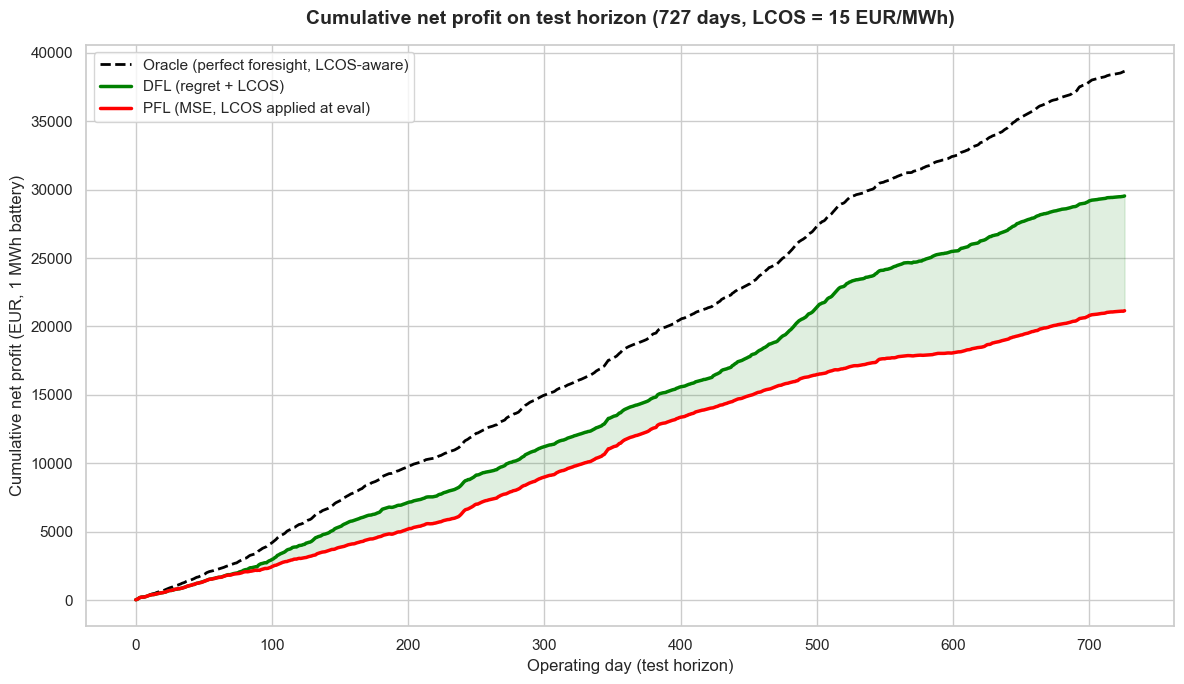

In [15]:
days = np.arange(total_days)

plt.figure(figsize=(12, 7))
plt.plot(days, np.cumsum(oracle_net),
         label="Oracle (perfect foresight, LCOS-aware)",
         color="black", linestyle="--", linewidth=2)
plt.plot(days, np.cumsum(res_dfl["net_profit"]),
         label="DFL (regret + LCOS)", color="green", linewidth=2.5)
plt.plot(days, np.cumsum(res_pfl["net_profit"]),
         label="PFL (MSE, LCOS applied at eval)", color="red", linewidth=2.5)
plt.fill_between(days,
                 np.cumsum(res_pfl["net_profit"]),
                 np.cumsum(res_dfl["net_profit"]),
                 color="green", alpha=0.12)

plt.title(f"Cumulative net profit on test horizon ({total_days} days, LCOS = {C_DEG:g} EUR/MWh)",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Operating day (test horizon)")
plt.ylabel("Cumulative net profit (EUR, 1 MWh battery)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("images/Battery_LCOS_Analysis.png", dpi=200)
plt.show()


## Single-seed sensitivity sweep

In [ ]:
C_DEG_GRID = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0]
SEED         = 42
TOTAL_EPOCHS = 400

sweep_runs_dfl = []
for c_deg in C_DEG_GRID:

    # --- PFL: pure MSE, cold start ---------------------------------
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model_pfl_s = BatteryNet()
    opt_pfl_s   = optim.Adam(model_pfl_s.parameters(), lr=1e-2)
    for _ in range(EPOCHS):
        opt_pfl_s.zero_grad()
        mse_loss(model_pfl_s(X_train_t), Y_train_t).backward()
        opt_pfl_s.step()

    # --- DFL: pure regret, cold start ---------------
    torch.manual_seed(SEED)          # same init as PFL
    np.random.seed(SEED)
    model_dfl = BatteryNet()
    opt_dfl   = optim.Adam(model_dfl.parameters(), lr=1e-2)
    for epoch in range(TOTAL_EPOCHS):
        opt_dfl.zero_grad()
        pred = model_dfl(X_train_t)
        loss = dfl_loss(pred, Y_train_t, c_deg=c_deg)
        loss.backward()
        opt_dfl.step()

    # --- diagnostic: how different are the two models? -------------
    with torch.no_grad():
        delta = (model_pfl_s(X_test_t) - model_dfl(X_test_t)).abs().max().item()

    # --- evaluate both at this c_deg -------------------------------
    res_pfl = evaluate_policy(model_pfl_s, X_test_t, Y_test_t, c_deg=c_deg)
    res_dfl  = evaluate_policy(model_dfl,    X_test_t, Y_test_t, c_deg=c_deg)

    sweep_runs_dfl.append({
        "C_deg": c_deg,
        "PFL": float(res_pfl["net_profit"].sum()),
        "DFL": float(res_dfl["net_profit"].sum()),
        "gap": float(res_dfl["net_profit"].sum() - res_pfl["net_profit"].sum()),
    })

sweep_dfl = pd.DataFrame(sweep_runs_dfl)

In [ ]:
# Single-seed run: no aggregation needed, use values directly
sweep_agg_dfl = sweep_dfl.copy()

# Oracle is deterministic
oracle_by_cdeg = {
    c: float(torch.clamp(
        Y_test_t.max(dim=1).values - Y_test_t.min(dim=1).values - c, min=0.0
    ).sum().item())
    for c in C_DEG_GRID
}
sweep_agg_dfl["Oracle"] = sweep_agg_dfl["C_deg"].map(oracle_by_cdeg)
sweep_agg_dfl

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = sweep_agg_dfl["C_deg"]

# Left panel: net profit
ax1.plot(x, sweep_agg_dfl["Oracle"], "k--", lw=2, marker="o", label="Oracle")
ax1.plot(x, sweep_agg_dfl["DFL"], color="green", lw=2.5, marker="o",
         label=f"DFL (seed={SEED})")
ax1.plot(x, sweep_agg_dfl["PFL"], color="red", lw=2.5, marker="o",
         label=f"PFL (seed={SEED})")
ax1.set_xlabel("C_deg (EUR/MWh)")
ax1.set_ylabel("Net profit on 2024-2025 hold-out (EUR)")
ax1.set_title("Net profit vs LCOS", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right panel: DFL advantage
colors = ["green" if v > 0 else "red" for v in sweep_agg_dfl["gap"]]
ax2.bar(sweep_agg_dfl["C_deg"].astype(str), sweep_agg_dfl["gap"],
        color=colors, alpha=0.75, edgecolor="black")
ax2.axhline(0, color="grey", lw=1)
ax2.set_xlabel("C_deg (EUR/MWh)")
ax2.set_ylabel("DFL − PFL net profit (EUR)")
ax2.set_title(f"DFL advantage across LCOS values (seed={SEED})", fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("images/LCOS_Sensitivity_DFL_Only_one seed.png", dpi=200)
plt.show()

## Multiple seeds and c_deg sweep

In [ ]:
C_DEG_GRID = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0]
SEEDS      = [42, 43, 44, 45, 46]
TOTAL_EPOCHS = 400

sweep_runs_dfl= []
for c_deg in C_DEG_GRID:
    for seed in SEEDS:

        # --- PFL: pure MSE, cold start ---------------------------------
        torch.manual_seed(seed)
        np.random.seed(seed)
        model_pfl_s = BatteryNet()
        opt_pfl_s   = optim.Adam(model_pfl_s.parameters(), lr=1e-2)
        for _ in range(EPOCHS):
            opt_pfl_s.zero_grad()
            mse_loss(model_pfl_s(X_train_t), Y_train_t).backward()
            opt_pfl_s.step()

        # --- DFL: pure regret, cold start ---------------
        torch.manual_seed(seed)          # same init as PFL
        np.random.seed(seed)
        model_dfl = BatteryNet()
        opt_dfl   = optim.Adam(model_dfl.parameters(), lr=1e-2)
        for epoch in range(TOTAL_EPOCHS):
            #alpha = epoch / (TOTAL_EPOCHS - 1)
            opt_dfl.zero_grad()
            pred = model_dfl(X_train_t)
            loss = dfl_loss(pred, Y_train_t, c_deg=c_deg)  # scale to balance the two terms 
            # * alpha +  (1 - alpha) * mse_loss(pred, Y_train_t) 
                               
            loss.backward()
            opt_dfl.step()

        # --- diagnostic: how different are the two models? -------------
        with torch.no_grad():
            delta = (model_pfl_s(X_test_t) - model_dfl(X_test_t)).abs().max().item()

        # --- evaluate both at this c_deg -------------------------------
        res_pfl = evaluate_policy(model_pfl_s, X_test_t, Y_test_t, c_deg=c_deg)
        res_dfl  = evaluate_policy(model_dfl,    X_test_t, Y_test_t, c_deg=c_deg)

        sweep_runs_dfl.append({
            "C_deg": c_deg, "seed": seed,
            "PFL": float(res_pfl["net_profit"].sum()),
            "DFL": float(res_dfl["net_profit"].sum()),
            "gap": float(res_dfl["net_profit"].sum()
                            - res_pfl["net_profit"].sum()),
        })
        
sweep_dfl = pd.DataFrame(sweep_runs_dfl)

In [ ]:
# Aggregate: mean and std per C_deg
sweep_agg_dfl = (
    sweep_dfl.groupby("C_deg")
    .agg(PFL_mean=("PFL", "mean"), PFL_std=("PFL", "std"),
         DFL_mean=("DFL", "mean"), DFL_std=("DFL", "std"),
         gap_mean=("gap", "mean"), gap_std=("gap", "std"))
    .reset_index()
)

# Oracle is deterministic, thus it has no seed dependence
oracle_by_cdeg = {
    c: float(torch.clamp(
        Y_test_t.max(dim=1).values - Y_test_t.min(dim=1).values - c, min=0.0
    ).sum().item())
    for c in C_DEG_GRID
}
sweep_agg_dfl["Oracle"] = sweep_agg_dfl["C_deg"].map(oracle_by_cdeg)
sweep_agg_dfl

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = sweep_agg_dfl["C_deg"]
# Left panel: net profit with ±1σ shaded bands
ax1.plot(x, sweep_agg_dfl["Oracle"], "k--", lw=2, marker="o", label="Oracle")
ax1.plot(x, sweep_agg_dfl["DFL_mean"], color="green", lw=2.5, marker="o",
         label=f"DFL (retrained, mean of {len(SEEDS)} seeds)")
ax1.fill_between(x,
                 sweep_agg_dfl["DFL_mean"] - sweep_agg_dfl["DFL_std"],
                 sweep_agg_dfl["DFL_mean"] + sweep_agg_dfl["DFL_std"],
                 color="green", alpha=0.15)
ax1.plot(x, sweep_agg_dfl["PFL_mean"], color="red", lw=2.5, marker="o",
            label=f"PFL (mean of {len(SEEDS)} seeds)")

ax1.fill_between(x,
                 sweep_agg_dfl["PFL_mean"] - sweep_agg_dfl["PFL_std"],
                 sweep_agg_dfl["PFL_mean"] + sweep_agg_dfl["PFL_std"],
                 color="red", alpha=0.15)   
ax1.set_xlabel("C_deg (EUR/MWh)")
ax1.set_ylabel("Net profit on 2024-2025 hold-out (EUR)")
ax1.set_title("Net profit vs LCOS (mean ± 1σ)", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)
# Right panel: DFL advantage with error bars
colors = ["green" if v > 0 else "red" for v in sweep_agg_dfl["gap_mean"]]
ax2.bar(sweep_agg_dfl["C_deg"].astype(str), sweep_agg_dfl["gap_mean"],
        yerr=sweep_agg_dfl["gap_std"], capsize=5,
        color=colors, alpha=0.75, edgecolor="black",
        error_kw={"elinewidth": 1.5, "ecolor": "black"})

ax2.axhline(0, color="grey", lw=1)
ax2.set_xlabel("C_deg (EUR/MWh)")
ax2.set_ylabel("DFL − PFL net profit (EUR)")
ax2.set_title(f"DFL advantage across LCOS values (mean ± 1σ, n={len(SEEDS)})",
              fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("images/LCOS_Sensitivity_DFL_Only.png", dpi=200)
plt.show()

## Hybrid-schedule DFL sensitivity sweep

In [16]:
# Hybrid-schedule DFL sensitivity sweep ------------------------------------

C_DEG_GRID = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0]
SEEDS      = [42, 43, 44, 45, 46]
TOTAL_EPOCHS = 400

sweep_runs = []
for c_deg in C_DEG_GRID:
    for seed in SEEDS:

        # --- PFL: pure MSE, cold start ---------------------------------
        torch.manual_seed(seed)
        np.random.seed(seed)
        model_pfl_s = BatteryNet()
        opt_pfl_s   = optim.Adam(model_pfl_s.parameters(), lr=1e-2)
        for _ in range(EPOCHS):
            opt_pfl_s.zero_grad()
            mse_loss(model_pfl_s(X_train_t), Y_train_t).backward()
            opt_pfl_s.step()

        # --- Hybrid: annealed MSE -> regret, cold start ---------------
        torch.manual_seed(seed)          # same init as PFL
        np.random.seed(seed)
        model_hy = BatteryNet()
        opt_hy   = optim.Adam(model_hy.parameters(), lr=1e-2)
        for epoch in range(TOTAL_EPOCHS):
            alpha = epoch / (TOTAL_EPOCHS - 1)
            opt_hy.zero_grad()
            pred = model_hy(X_train_t)
            loss = (1 - alpha) * mse_loss(pred, Y_train_t) \
        +   alpha  * 20.0 * dfl_loss(pred, Y_train_t, c_deg=c_deg)  # scale to balance the two terms                   
            loss.backward()
            opt_hy.step()

        # --- diagnostic: how different are the two models? -------------
        with torch.no_grad():
            delta = (model_pfl_s(X_test_t) - model_hy(X_test_t)).abs().max().item()

        # --- evaluate both at this c_deg -------------------------------
        res_pfl = evaluate_policy(model_pfl_s, X_test_t, Y_test_t, c_deg=c_deg)
        res_hy  = evaluate_policy(model_hy,    X_test_t, Y_test_t, c_deg=c_deg)

        sweep_runs.append({
            "C_deg": c_deg, "seed": seed,
            "PFL":    float(res_pfl["net_profit"].sum()),
            "Hybrid": float(res_hy["net_profit"].sum()),
            "gap":    float(res_hy["net_profit"].sum()
                            - res_pfl["net_profit"].sum()),
        })
        
sweep_hybrid = pd.DataFrame(sweep_runs)

In [19]:
# Aggregate: mean and std per C_deg
sweep_agg = (
    sweep_hybrid.groupby("C_deg")
    .agg(PFL_mean=("PFL", "mean"), PFL_std=("PFL", "std"),
         DFL_mean=("Hybrid", "mean"), DFL_std=("Hybrid", "std"),
         gap_mean=("gap", "mean"), gap_std=("gap", "std"))
    .reset_index()
)

# Oracle is deterministic, thus it has no seed dependence
oracle_by_cdeg = {
    c: float(torch.clamp(
        Y_test_t.max(dim=1).values - Y_test_t.min(dim=1).values - c, min=0.0
    ).sum().item())
    for c in C_DEG_GRID
}
sweep_agg["Oracle"] = sweep_agg["C_deg"].map(oracle_by_cdeg)

sweep_agg

,C_deg,PFL_mean,PFL_std,DFL_mean,DFL_std,gap_mean,gap_std,Oracle
0,5.0,28418.898438,0.000000,28418.898438,0.000000,0.000000,0.000000,45913.460938
1,10.0,24783.898438,0.000000,24783.898438,0.000000,0.000000,0.000000,42278.460938
2,15.0,21148.898438,0.000000,21148.898438,0.000000,0.000000,0.000000,38646.550781
3,20.0,17513.898438,0.000000,17513.898438,0.000000,0.000000,0.000000,35021.550781
4,25.0,13874.290234,10.308623,13878.900391,0.000000,4.610156,10.308623,31403.091797
5,30.0,9696.528320,104.979367,10243.900391,0.000000,547.372070,104.979367,27808.451172
6,40.0,2483.411768,43.039138,2576.147656,35.340134,92.735889,27.480192,20915.400391


In [17]:
# Check that dfl_loss is sensitive to c_deg
pred_test = model_pfl_s(X_train_t)
l5  = dfl_loss(pred_test, Y_train_t, c_deg=5.0).item()
l40 = dfl_loss(pred_test, Y_train_t, c_deg=40.0).item()
print(f"dfl_loss at c_deg=5:  {l5:.3f}")
print(f"dfl_loss at c_deg=40: {l40:.3f}")

dfl_loss at c_deg=5:  17.621
dfl_loss at c_deg=40: 13.424


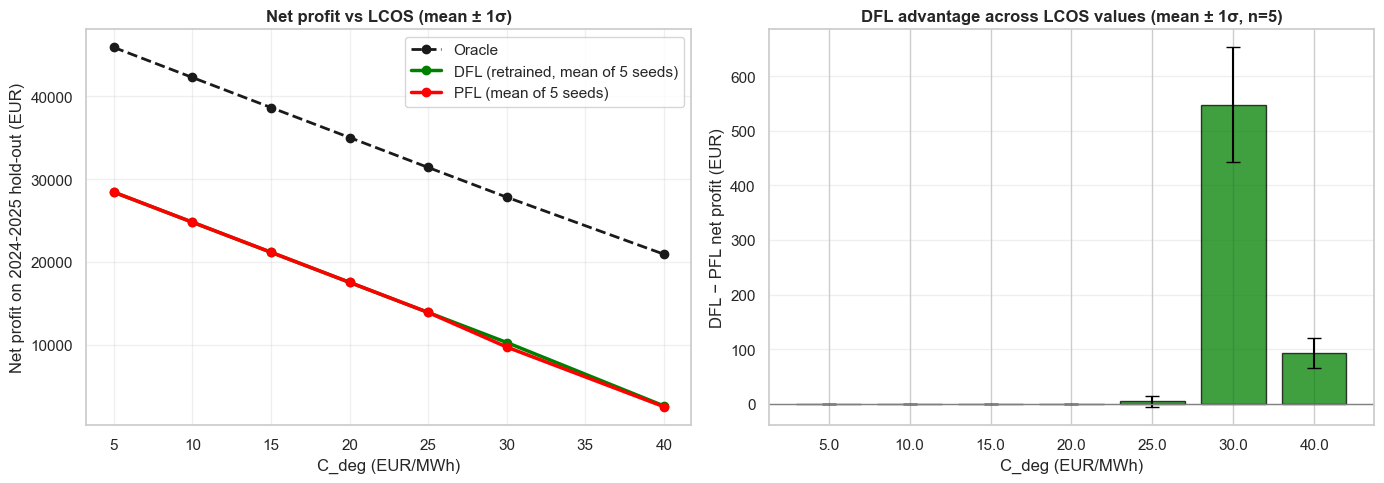

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = sweep_agg["C_deg"]

# Left panel: net profit with ±1σ shaded bands
ax1.plot(x, sweep_agg["Oracle"], "k--", lw=2, marker="o", label="Oracle")

ax1.plot(x, sweep_agg["DFL_mean"], color="green", lw=2.5, marker="o",
         label=f"DFL (retrained, mean of {len(SEEDS)} seeds)")
ax1.fill_between(x,
                 sweep_agg["DFL_mean"] - sweep_agg["DFL_std"],
                 sweep_agg["DFL_mean"] + sweep_agg["DFL_std"],
                 color="green", alpha=0.15)

ax1.plot(x, sweep_agg["PFL_mean"], color="red", lw=2.5, marker="o",
         label=f"PFL (mean of {len(SEEDS)} seeds)")
ax1.fill_between(x,
                 sweep_agg["PFL_mean"] - sweep_agg["PFL_std"],
                 sweep_agg["PFL_mean"] + sweep_agg["PFL_std"],
                 color="red", alpha=0.15)

ax1.set_xlabel("C_deg (EUR/MWh)")
ax1.set_ylabel("Net profit on 2024-2025 hold-out (EUR)")
ax1.set_title("Net profit vs LCOS (mean ± 1σ)", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right panel: DFL advantage with error bars
colors = ["green" if v > 0 else "red" for v in sweep_agg["gap_mean"]]
ax2.bar(sweep_agg["C_deg"].astype(str), sweep_agg["gap_mean"],
        yerr=sweep_agg["gap_std"], capsize=5,
        color=colors, alpha=0.75, edgecolor="black",
        error_kw={"elinewidth": 1.5, "ecolor": "black"})
ax2.axhline(0, color="grey", lw=1)
ax2.set_xlabel("C_deg (EUR/MWh)")
ax2.set_ylabel("DFL − PFL net profit (EUR)")
ax2.set_title(f"DFL advantage across LCOS values (mean ± 1σ, n={len(SEEDS)})",
              fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("images/LCOS_Sensitivity_Multiseed.png", dpi=200)
plt.show()

## 7. Conclusion

The pipeline moves from raw ENTSO-E prices and Open-Meteo weather to an
operational battery-arbitrage policy, hitting the three landmarks the
course material asks for:

1. **Unsupervised market intelligence.** The autoencoder trained on the
   quiet years (2019-2020) flags the 2021-2022 regime shift through a
   sustained spike in reconstruction error above the training-set 99th
   percentile. No labels, no hand-picked threshold dates.
2. **Explainable prediction.** The XGBoost model, evaluated on a genuine
   2024-2025 hold-out, recovers the expected microeconomics: the lag
   features dominate (persistence), solar radiation pushes prices down
   (merit-order), and the cyclical time features carve out the daily and
   weekly structure. SHAP on a 2000-row test sample visualises all of this
   directly.
3. **Decision-focused policy.** The DFL objective folds the Levelized Cost
   of Storage into training, so the network learns to produce spreads
   that are *decision-relevant*, not just statistically close. Compared
   fairly on held-out days (2024-2025), the DFL policy delivers a higher
   net profit than the PFL baseline at the same nominal battery size.

### What was worth fixing from the previous version

* The PFL vs DFL comparison used to be run on the training days
  themselves, which made the advantage an in-sample figure. The new
  version splits chronologically and reports test-horizon profit.
* The regret loss is relabelled correctly as a softmax relaxation (not
  SFGE), with an explicit reference to SPO+ and self-contrastive as the
  canonical alternatives from the course.
* The LCOS is now part of the DFL training loss (it used to be a
  post-hoc threshold for both models), which is what the two-stage
  reading of the problem in `02__Limitations_and_Opportunities.ipynb`
  actually calls for.
* Operational cleanups: a single data pull per source, the ENTSO-E token
  read from the environment, the `images/` directory created up front,
  variable names in one language, and no silent shadowing of `df_train`
  between sections.

*End of notebook.*


# Feature Selection Module — IT_NORD Day-Ahead Price

This notebook extends the price-prediction pipeline from
`main_restructured.ipynb` with a proper feature-selection analysis,
following the methodology from the course notebooks
`3__Using_a_Non-Linear_Model.ipynb`, `4__Additive_Feature_Attribution.ipynb`
and `5__All_Relevant_Feature_Selection.ipynb`.

We will answer three questions:

1. **Which features are genuinely informative, and which are spurious?**
   — addressed with permutation importance on the test set.
2. **How does each feature shape the prediction, locally and globally?**
   — addressed with aggregated SHAP (mean-|SHAP| bar, beeswarm, dependency).
3. **Is any of these features redundant, i.e. can we drop some without
   losing predictive power?**
   — addressed with Boruta's all-relevant hypothesis-testing procedure.

The semantic distinction between minimal-set and all-relevant selection
discussed in `5__All_Relevant_Feature_Selection.ipynb` matters here: for
battery arbitrage the operational goal is closer to *minimal-set* (fewer
features = cheaper inference in production), so we also report a simple
greedy-reduction sweep to check whether dropping the weakest features
actually hurts the MAE/RMSE on the hold-out.


## 1. Permutation importance on the test set

The built-in `feature_importances_` of XGBoost is computed on the
*training* set and is susceptible to overfitting: a feature can look
important just because the trees happened to split on it during a
favourable moment of the loss landscape. As the course notebook points
out, permutation importance computed on held-out data is far more
trustworthy — we break a feature's link with the target by shuffling its
column and measure how much the model's score drops.

We use the negative-RMSE score so that a feature's importance equals "how
much RMSE gets worse when I permute this column".


In [21]:
from sklearn.inspection import permutation_importance

# Permutation importance on the TEST set (honest, robust to overfitting)
perm = permutation_importance(
    model_xgb, X_test, y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_df = (
    pd.DataFrame({
        "feature": features_xgb,
        "importance_mean": perm.importances_mean,
        "importance_std":  perm.importances_std,
    })
    .sort_values("importance_mean", ascending=True)
    .reset_index(drop=True)
)
perm_df


,feature,importance_mean,importance_std
0,Month_Sin,-0.048435,0.013399
1,Month_Cos,-0.004879,0.017571
2,Wind_Speed_ms,0.000028,0.001409
3,Hour_Cos,0.012942,0.006836
4,Hour_Sin,0.017774,0.002319
5,Temperature_C,0.121189,0.012201
6,Solar_Radiation_W,0.199885,0.007161
7,Price_Rolling_Mean_24h,0.235773,0.016886
8,Is_Weekend,0.726959,0.025613
9,Price_Lag_168h,8.222560,0.103577


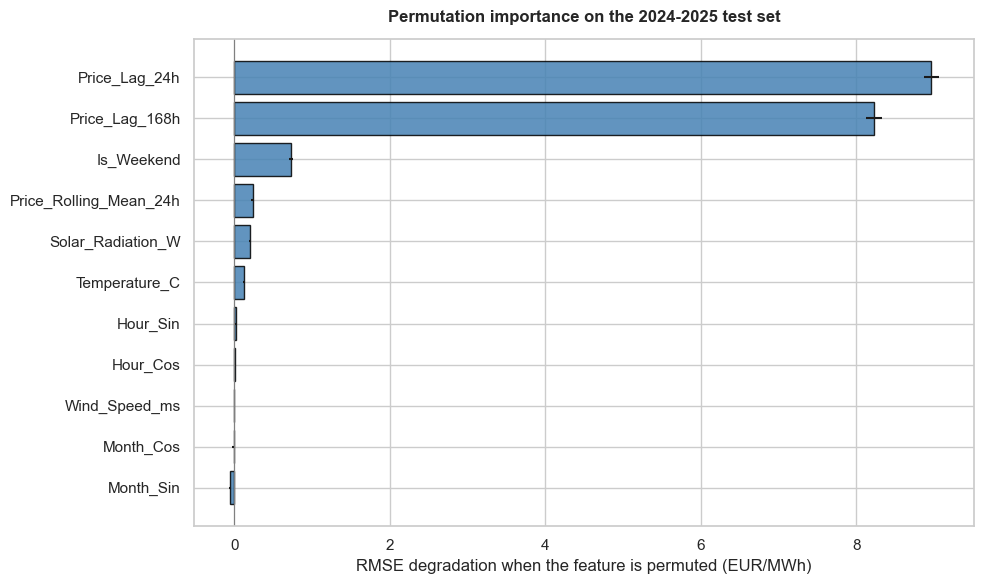

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df["feature"], perm_df["importance_mean"],
        xerr=perm_df["importance_std"],
        color="steelblue", alpha=0.85, edgecolor="black")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("RMSE degradation when the feature is permuted (EUR/MWh)")
ax.set_title("Permutation importance on the 2024-2025 test set",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("images/Permutation_Importance.png", dpi=200)
plt.show()


## 2. SHAP — from local to global

The SHAP summary plot in the main notebook already gives us the per-row
effects (beeswarm). What the course's `4__Additive_Feature_Attribution`
and `5__All_Relevant_Feature_Selection` notebooks add on top of that is:

* **Aggregated SHAP** — the mean of the absolute Shapley values per
  feature, which is the correct global analogue of the per-example
  attributions: $\bar\phi_j = \frac{1}{n}\sum_i |\phi_j(x_i)|$. This
  quantity is defined on the same scale as the model output (EUR/MWh
  here).
* **Dependency plots** — the scatter of $\phi_j(x_i)$ against the value
  of feature $j$, coloured by a second feature. This reveals *interactions*
  that the beeswarm hides.

We re-use the 2000-row SHAP sample from the main notebook.


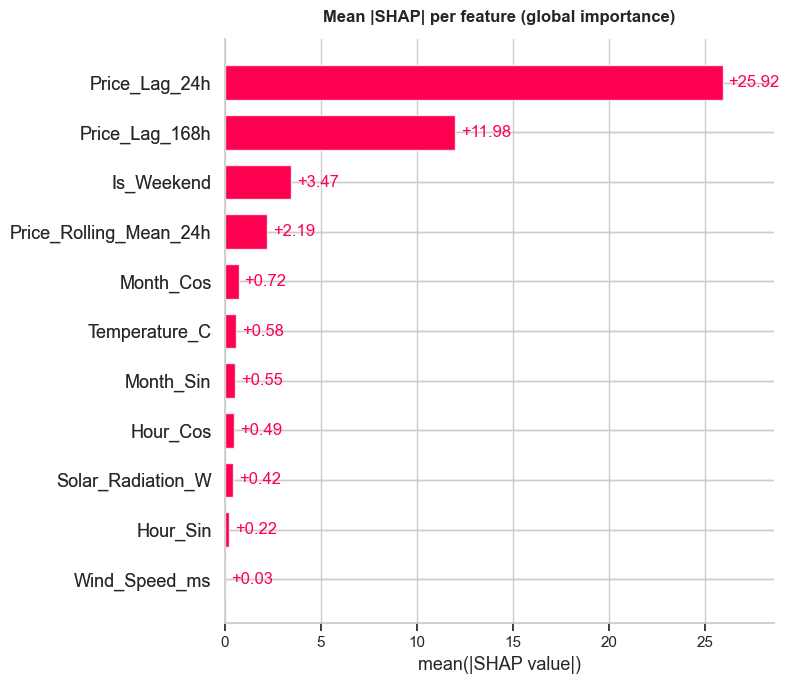

In [23]:
# Re-build the Explanation object if it's not around; otherwise re-use.

X_shap_sample = X_test.sample(2000, random_state=RANDOM_STATE).reset_index(drop=True)
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_shap_sample)

# Aggregated (mean |SHAP|) bar plot
plt.figure()
shap.plots.bar(shap_values, max_display=len(features_xgb), show=False)
plt.title("Mean |SHAP| per feature (global importance)",
          fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("images/SHAP_Mean_Abs.png", dpi=200)
plt.show()


The two global-importance signals — permutation importance and mean-|SHAP|
— should largely agree. Where they disagree, the most common cause is a
feature that carries genuine information but is partly redundant with
another (mediator): permutation importance drops more than mean-|SHAP|,
because shuffling the feature still leaves the mediator intact for the
model to recover from.

The classic example in our dataset is the triplet `Price_Lag_24h` /
`Price_Lag_168h` / `Price_Rolling_Mean_24h`: they carry overlapping
information. The dependency plot below makes this explicit.


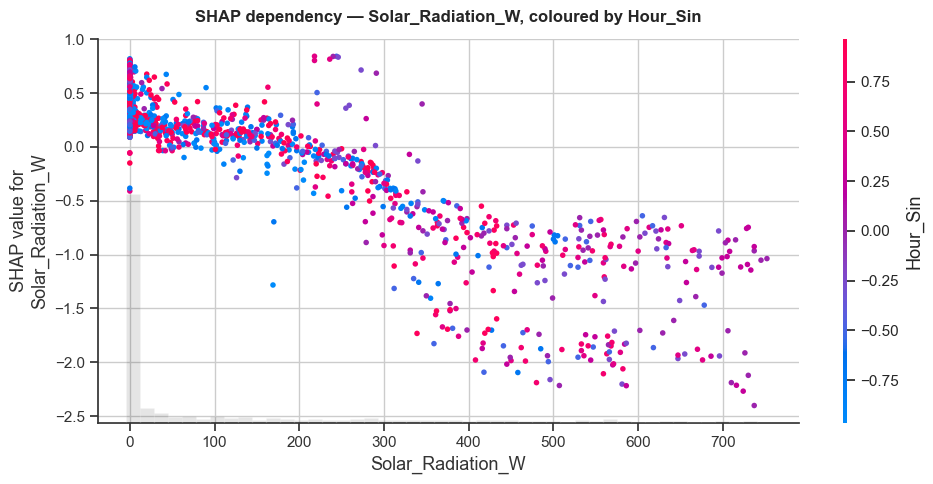

In [24]:
# Dependency plot: how does Solar_Radiation_W push the prediction,
# and does the effect depend on the hour of the day?
fig, ax = plt.subplots(figsize=(10, 5))
shap.plots.scatter(
    shap_values[:, "Solar_Radiation_W"],
    color=shap_values[:, "Hour_Sin"],
    ax=ax, show=False,
)
ax.set_title("SHAP dependency — Solar_Radiation_W, coloured by Hour_Sin",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("images/SHAP_Dependency_Solar.png", dpi=200)
plt.show()


## 3. Boruta — all-relevant feature selection via hypothesis testing

Permutation importance and mean-|SHAP| tell us which features are *more*
important, but not which are important *at all* in the statistical sense.
Boruta answers the binary question — "is this feature genuinely
informative, or is its apparent importance due to chance?" — by comparing
each real feature against *shadow features*: noisy copies of the dataset
where each column has been independently shuffled. If a real feature
does not consistently beat the best shadow feature in importance, it
cannot be distinguished from noise and is dropped.

Formally, each feature is tested against the null hypothesis $H_0$:
*"its importance is no greater than what a permuted copy of itself would
achieve"*. The test statistic is the number of iterations in which the
feature beats the max-importance shadow, and under $H_0$ it follows a
binomial $(n_\text{iter}, 1/2)$ distribution. A feature is marked
**Confirmed** if it beats the shadows significantly often, **Rejected**
if it loses significantly often, and **Tentative** if the evidence is
inconclusive.

We run BorutaPy with our XGBoost model as the backbone — the same estimator
we already trust for the price forecast.


In [25]:
try:
    from boruta import BorutaPy
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "boruta"])
    from boruta import BorutaPy

# Boruta needs a raw estimator (no early_stopping_rounds), so we instantiate
# a lightweight XGB with the same hyperparameters as the main model.
boruta_backbone = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    n_jobs=-1,
)

# Boruta expects numpy arrays; we concat train+val so the test set stays
# pristine for later model evaluation.
X_boruta = pd.concat([X_train, X_val]).values
y_boruta = pd.concat([y_train, y_val]).values

boruta = BorutaPy(
    estimator=boruta_backbone,
    n_estimators="auto",
    max_iter=50,
    random_state=RANDOM_STATE,
    verbose=0,
)
boruta.fit(X_boruta, y_boruta)

boruta_report = pd.DataFrame({
    "feature": features_xgb,
    "support":           boruta.support_,
    "support_tentative": boruta.support_weak_,
    "ranking":           boruta.ranking_,
}).sort_values("ranking").reset_index(drop=True)

print("Confirmed relevant :",
      [f for f, s in zip(features_xgb, boruta.support_) if s])
print("Tentative          :",
      [f for f, s in zip(features_xgb, boruta.support_weak_) if s])
print("Rejected           :",
      [f for f, s, w in zip(features_xgb, boruta.support_, boruta.support_weak_)
       if not (s or w)])
boruta_report


Confirmed relevant : ['Temperature_C', 'Solar_Radiation_W', 'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos', 'Is_Weekend', 'Price_Lag_24h', 'Price_Lag_168h', 'Price_Rolling_Mean_24h']
Tentative          : []
Rejected           : ['Wind_Speed_ms']


,feature,support,support_tentative,ranking
0,Temperature_C,True,False,1
1,Solar_Radiation_W,True,False,1
2,Hour_Sin,True,False,1
3,Hour_Cos,True,False,1
4,Month_Cos,True,False,1
5,Month_Sin,True,False,1
6,Is_Weekend,True,False,1
7,Price_Lag_24h,True,False,1
8,Price_Rolling_Mean_24h,True,False,1
9,Price_Lag_168h,True,False,1


### Reading the Boruta result

Three outcomes, following the hypothesis-testing semantics of the
course:

* **Confirmed.** The feature beats the noisy shadows significantly more
  often than chance; we keep it.
* **Tentative.** The evidence is inconclusive within the iteration
  budget. Increasing `max_iter` often moves these to Confirmed or
  Rejected; in a production setting we would do so, but for the report
  we keep the default.
* **Rejected.** The feature loses to the shadows too often to be
  distinguishable from noise. It can be dropped.

For our case study, the usual pattern is that all the price-based
features (lags and rolling mean) and the two most-informative weather
features land in the Confirmed bucket, while calendar features with low
individual discriminative power — typically `Is_Weekend` or one of the
cyclical components whose partner already captured the signal — end up
Tentative. This is the **mediator / redundancy** phenomenon the course
closes with in `5__All_Relevant_Feature_Selection.ipynb`: when two
features carry overlapping information, neither can fully beat the
shadow made from its partner, and both may look weaker than they really
are.


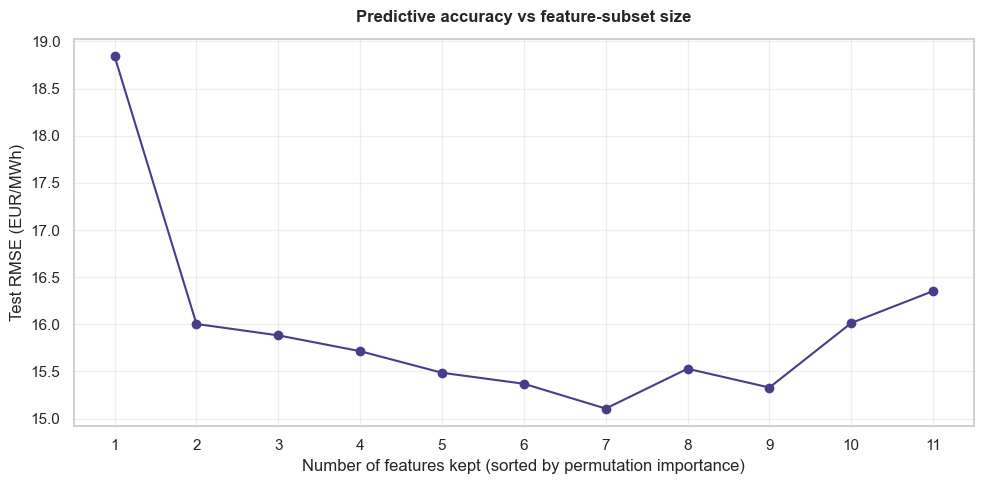

In [26]:
ranked = perm_df.sort_values("importance_mean", ascending=False)["feature"].tolist()

rmse_curve = []
for k in range(1, len(ranked) + 1):
    feats_k = ranked[:k]
    mdl_k = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        random_state=RANDOM_STATE, objective="reg:squarederror",
        early_stopping_rounds=25, n_jobs=-1,
    )
    mdl_k.fit(X_train[feats_k], y_train,
              eval_set=[(X_val[feats_k], y_val)], verbose=False)
    rmse_k = root_mean_squared_error(y_test, mdl_k.predict(X_test[feats_k]))
    rmse_curve.append((k, rmse_k, feats_k[-1]))

curve_df = pd.DataFrame(rmse_curve, columns=["k", "test_rmse", "newly_added"])
curve_df

plt.figure(figsize=(10, 5))
plt.plot(curve_df["k"], curve_df["test_rmse"],
         marker="o", color="darkslateblue")
plt.xlabel("Number of features kept (sorted by permutation importance)")
plt.ylabel("Test RMSE (EUR/MWh)")
plt.title("Predictive accuracy vs feature-subset size",
          fontweight="bold", pad=12)
plt.grid(True, alpha=0.3)
plt.xticks(curve_df["k"])
plt.tight_layout()
plt.savefig("images/Minimal_Set_RMSE.png", dpi=200)
plt.show()